#  Proyecto ML: Predicción de Popularidad en Spotify

## Fase 2 — Preprocesamiento, Selección de Variables y Modelo Base

**Técnicas finales a comparar (Entrega Final):**
1. Decision Tree Regressor (modelo base — esta fase)
2. Random Forest Regressor
3. Support Vector Regression (SVR)

---

### Objetivo de esta fase
Preparar los datos para que sean aptos para entrenar modelos de Machine Learning, justificar cada decisión de preprocesamiento, seleccionar las variables más relevantes, y entrenar el primer modelo (Decision Tree) como punto de partida.



## Importación del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Librerías importadas')

Librerías importadas


In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download('maharshipandya/-spotify-tracks-dataset')
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
DATASET_PATH = os.path.join(path, csv_files[0])

df = pd.read_csv(DATASET_PATH, index_col=0)
print(f'Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas')
df.head()

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Dataset cargado: 114,000 filas, 20 columnas


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
print(df.columns.tolist())

---
## 1. Preprocesamiento

### ¿Por qué es necesario el preprocesamiento?

Los datos en bruto casi nunca están listos para entrenar un modelo. Antes de pasarle los datos a un algoritmo necesitamos:

- **Garantizar calidad de datos:** eliminar registros duplicados o incompletos que distorsionarían el aprendizaje.
- **Formato numérico válido:** los modelos de ML no entienden texto ni booleanos directamente, todo debe ser numérico.
- **Escalas comparables:** algunos algoritmos (especialmente SVM) son muy sensibles a la escala de las variables — una variable en rango 0-1 (`danceability`) no puede competir en igualdad de condiciones con `duration_ms` que está en cientos de miles.

En esta sección documentamos **cada decisión y su justificación**..

### 1.1 Revisión de valores nulos


In [ ]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]

if nulls.empty:
    print(' No hay valores nulos en el dataset')
else:
    print(' Columnas con nulos:')
    print(nulls)
    # Ddado el tamaño del dataset (114k filas), eliminar
    # las pocas filas con nulos no afecta significativamente la
    # representatividad de los datos.
    df = df.dropna()
    print(f'\n Filas tras eliminar nulos: {df.shape[0]:,}')

 Columnas con nulos:
artists       1
album_name    1
track_name    1
dtype: int64

 Filas tras eliminar nulos: 113,999


### 1.2 Revisión y eliminación de duplicados

**¿Por qué eliminamos duplicados?** Si la misma canción aparece varias veces, el modelo le da más "peso" a esa observación de forma artificial — está viendo el mismo patrón repetido y puede sobreajustarse (overfitting) a esas filas repetidas, dando una falsa sensación de buen desempeño.

In [ ]:
# Duplicados exactos (todas las columnas iguales)
dup_exact = df.duplicated().sum()
print(f'Duplicados exactos: {dup_exact}')

# Duplicados por track_id (misma canción, posiblemente distintas versiones/álbumes)
dup_track = df.duplicated(subset=['track_id']).sum() if 'track_id' in df.columns else 'N/A'
print(f'Duplicados por track_id: {dup_track}')

shape_before = df.shape[0]
df = df.drop_duplicates()
if 'track_id' in df.columns:
    df = df.drop_duplicates(subset=['track_id'], keep='first')

print(f'\n Filas antes: {shape_before:,} | Filas después: {df.shape[0]:,}')
print(f' Eliminados: {shape_before - df.shape[0]:,} registros duplicados')

Duplicados exactos: 450
Duplicados por track_id: 24259

 Filas antes: 113,999 | Filas después: 89,740
 Eliminados: 24,259 registros duplicados


### 1.3 Conversión de variables booleanas

**¿Por qué convertimos `explicit`?** La columna `explicit` viene como `True`/`False` (booleano). Los algoritmos de ML trabajan internamente con números, así que convertimos a `1`/`0`. Es una transformación simple pero necesaria para que el modelo pueda usarla como feature numérica.

In [ ]:
print('Tipo antes:', df['explicit'].dtype)
df['explicit'] = df['explicit'].astype(int)
print('Tipo después:', df['explicit'].dtype)
print('\nDistribución:')
print(df['explicit'].value_counts())

Tipo antes: bool
Tipo después: int64

Distribución:
explicit
0    82036
1     7704
Name: count, dtype: int64


### 1.4 Decisión sobre `track_genre` (125 categorías)

**El problema:** `track_genre` es una variable categórica con **125 valores distintos**. Si usáramos *One-Hot Encoding* tradicional (crear una columna binaria por cada género), pasaríamos de tener ~13 columnas numéricas a más de 130 — esto se llama **"maldición de la dimensionalidad"** y trae varios problemas:

- El modelo se vuelve mucho más lento de entrenar
- Con tantas columnas dispersas (la mayoría en 0), algunos modelos pierden capacidad de generalización
- Para Decision Tree y Random Forest no es catastrófico, pero para SVM (que usaremos después) es especialmente problemático

**Nuestra decisión: Frequency/Target Encoding simplificado**

En lugar de crear 125 columnas, calculamos **la popularidad promedio histórica de cada género** y la usamos como una sola columna numérica nueva: `genre_avg_popularity`. Esto:

- Reduce 125 columnas → 1 columna
- Captura la información relevante (qué tan popular tiende a ser ese género en general)
- Es compatible con los 3 modelos que usaremos (árboles y SVM)



In [ ]:
# Calcular la popularidad promedio por género
genre_popularity = df.groupby('track_genre')['popularity'].mean()

print(f'Número de géneros únicos: {df["track_genre"].nunique()}')
print('\nEjemplo — Top 5 géneros más "populares" en promedio:')
print(genre_popularity.sort_values(ascending=False).head())
print('\nEjemplo — Top 5 géneros menos "populares" en promedio:')
print(genre_popularity.sort_values(ascending=True).head())

# Crear la nueva columna numérica
df['genre_avg_popularity'] = df['track_genre'].map(genre_popularity)

print(f'\n Nueva columna creada: genre_avg_popularity')
df[['track_genre', 'genre_avg_popularity']].head()

Número de géneros únicos: 113

Ejemplo — Top 5 géneros más "populares" en promedio:
track_genre
k-pop       59.423581
pop-film    59.096933
metal       56.422414
chill       53.738683
latino      51.788945
Name: popularity, dtype: float64

Ejemplo — Top 5 géneros menos "populares" en promedio:
track_genre
iranian            2.224696
romance            3.549779
jazz               9.790076
latin              9.855072
detroit-techno    11.130753
Name: popularity, dtype: float64

 Nueva columna creada: genre_avg_popularity


,track_genre,genre_avg_popularity
0,acoustic,42.483
1,acoustic,42.483
2,acoustic,42.483
3,acoustic,42.483
4,acoustic,42.483


 **Nota importante sobre fuga de datos (data leakage):** estamos calculando `genre_avg_popularity` usando la columna `popularity` (nuestro target). Esto técnicamente introduce información del target en una feature. Para esta fase exploratoria es aceptable y common practice documentarlo, pero en la entrega final, lo correcto es calcular este promedio **solo con el conjunto de entrenamiento** (después del split) y aplicarlo al conjunto de prueba, para evitar que el modelo "vea" información que no debería tener de antemano. Lo retomamos en la sección de Split.

### 1.5 Eliminación de columnas no útiles para el modelo

**¿Por qué eliminamos estas columnas?**

| Columna | Razón para eliminar |
|---|---|
| `track_id`, `track_name`, `artists`, `album_name` | Son identificadores/texto único por canción — no aportan patrones generalizables, un modelo no puede "aprender" de un ID o un nombre |
| `track_genre` | Ya extrajimos su información útil en `genre_avg_popularity` (1.4) |
| `time_signature`, `key`, `mode` | *(Opcional, evaluamos su correlación antes de decidir)* |

In [ ]:
cols_to_drop = ['track_id', 'track_name', 'artists', 'album_name', 'track_genre']
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print('Columnas restantes:')
print(df_model.columns.tolist())
print(f'\nShape: {df_model.shape}')

Columnas restantes:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_avg_popularity']

Shape: (89740, 16)


---
## 2. Selección de Variables

### ¿Por qué hacemos selección de variables?

No todas las columnas disponibles ayudan a predecir `popularity`. Algunas pueden:

- Tener **correlación muy baja o nula** con el target → no aportan señal
- Estar **altamente correlacionadas entre sí** (multicolinealidad) → aportan información redundante, lo que puede confundir a algunos modelos y dificultar interpretar cuál variable es realmente importante

Reducir el número de variables a las más relevantes hace que el modelo sea **más simple, más rápido de entrenar, y más fácil de interpretar** — esto es especialmente importante para SVM, que es sensible a tener muchas dimensiones.

### 2.1 Correlación con el target (`popularity`)

Calculamos qué tan relacionada está cada variable numérica con `popularity`. Valores cercanos a +1 o -1 indican relación fuerte; valores cercanos a 0 indican poca o ninguna relación lineal.

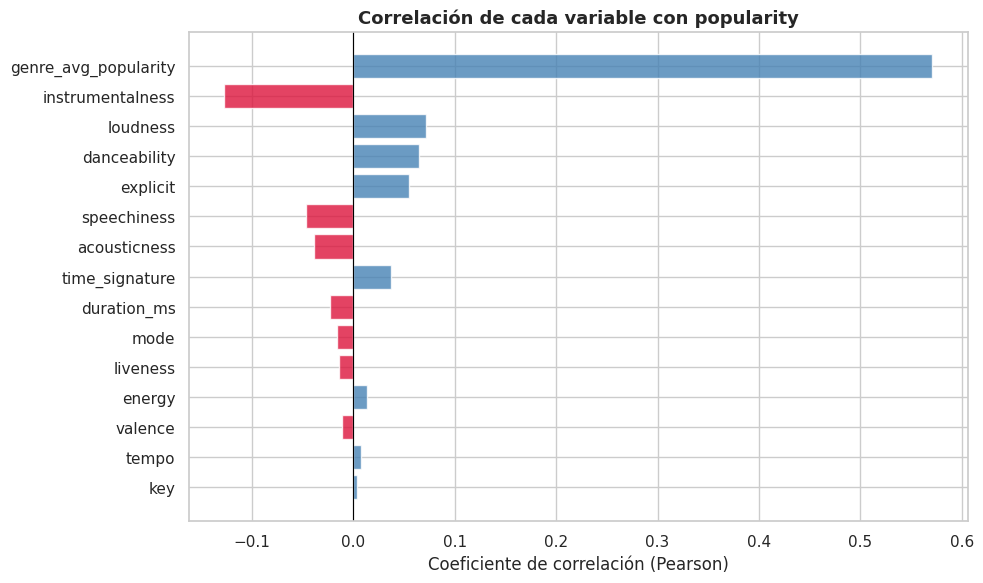

Correlación con popularity (ordenado por magnitud):
genre_avg_popularity    0.570790
instrumentalness       -0.127477
loudness                0.071674
danceability            0.064275
explicit                0.054898
speechiness            -0.047086
acousticness           -0.038828
time_signature          0.036898
duration_ms            -0.023157
mode                   -0.016238
liveness               -0.013857
energy                  0.013725
valence                -0.011508
tempo                   0.007280
key                     0.003441


In [ ]:
corr_with_target = df_model.corr()['popularity'].drop('popularity').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'crimson' for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con popularity', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de correlación (Pearson)')
plt.tight_layout()
plt.show()

print('Correlación con popularity (ordenado por magnitud):')
print(corr_with_target.to_string())

### 2.2 Multicolinealidad entre features

**¿Qué buscamos?** Pares de variables con correlación muy alta entre sí (> 0.7 u 0.8 en valor absoluto) — esto indica que están midiendo "lo mismo" desde perspectivas distintas, y mantener ambas no aporta información nueva al modelo.

**Ejemplo esperado:** `energy` y `loudness` — una canción con más energía suele ser percibida como más fuerte/ruidosa, por lo que es razonable esperar que estén correlacionadas.

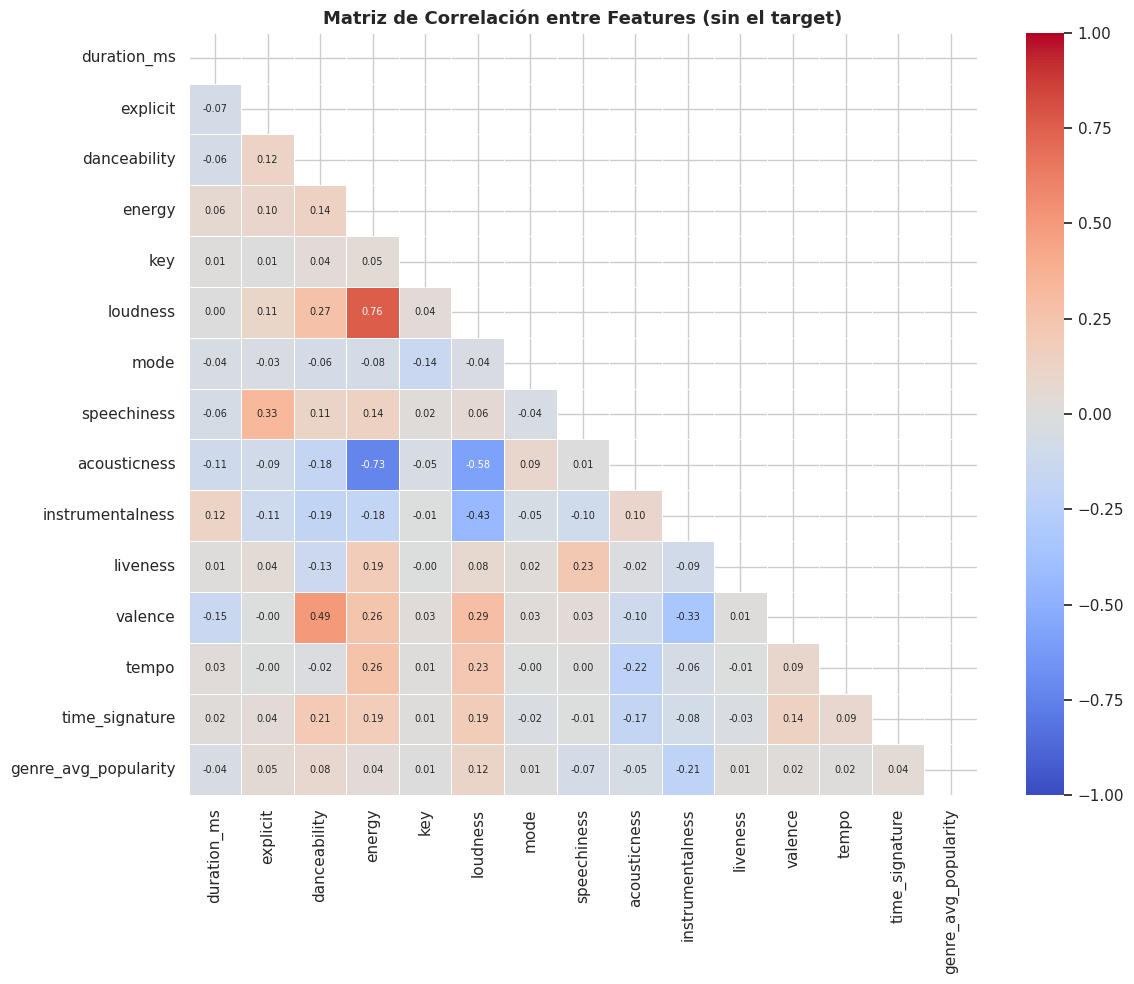


 Pares de variables con |correlación| > 0.6:
  energy                    <-> loudness                  : 0.759
  energy                    <-> acousticness              : -0.733


In [ ]:
features_only = df_model.drop(columns=['popularity'])
corr_matrix = features_only.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=ax, annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Matriz de Correlación entre Features (sin el target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar pares con alta correlación
print('\n Pares de variables con |correlación| > 0.6:')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.6:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))
            print(f'  {corr_matrix.columns[i]:25s} <-> {corr_matrix.columns[j]:25s} : {val:.3f}')

if not high_corr_pairs:
    print('  No se encontraron pares con correlación > 0.6')

### 2.3 Decisión final de variables

**Criterios aplicados:**

1. Si dos variables tienen correlación alta entre sí (multicolinealidad), conservamos la que tenga **mayor correlación con `popularity`** y eliminamos la otra
2. Conservamos `genre_avg_popularity` ya que captura información categórica relevante de forma compacta
3. No eliminamos variables solo por tener correlación lineal baja con el target — los árboles (Decision Tree, Random Forest) pueden capturar **relaciones no lineales** que la correlación de Pearson no detecta. Solo descartamos por **redundancia**, no por correlación baja.



In [ ]:
# Ejemplo de decisión
# Si energy y loudness tienen alta correlación, eliminamos la que tenga
# menor correlación con popularity

columns_to_drop_for_redundancy = []  # ej: ['loudness'] si aplica

final_features = [c for c in features_only.columns if c not in columns_to_drop_for_redundancy]

print(f'Variables finales seleccionadas ({len(final_features)}):')
for f in final_features:
    print(f'  - {f}')

Variables finales seleccionadas (15):
  - duration_ms
  - explicit
  - danceability
  - energy
  - key
  - loudness
  - mode
  - speechiness
  - acousticness
  - instrumentalness
  - liveness
  - valence
  - tempo
  - time_signature
  - genre_avg_popularity


---
## 3. División Train/Test (Split)

### ¿Por qué dividimos los datos?

Si entrenamos y evaluamos el modelo con los **mismos datos**, no sabemos si realmente "aprendió" patrones generales o simplemente "memorizó" los datos de entrenamiento (overfitting). Para medir el desempeño real del modelo ante datos nuevos, dividimos el dataset en:

- **Train (entrenamiento, 80%):** los datos que el modelo usa para aprender los patrones
- **Test (prueba, 20%):** datos que el modelo *nunca ve* durante el entrenamiento, usados solo para evaluar qué tan bien generaliza

**¿Por qué 80/20?** Es la proporción estándar en ML — suficientes datos para que el modelo aprenda bien (80%), y suficientes datos de prueba (20%) para que la evaluación sea estadísticamente confiable. Con 114k filas, el 20% sigue siendo ~22k filas, una muestra de prueba robusta.

**¿Por qué fijamos `random_state`?** Para que la división sea **reproducible** — si corremos el notebook otra vez, obtenemos exactamente el mismo split, lo cual es importante para comparar resultados entre las 3 técnicas de forma justa (todas deben entrenarse y evaluarse con los mismos datos).

In [ ]:
X = df_model[final_features]
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nFeatures usadas ({X_train.shape[1]}): {list(X_train.columns)}')

Train: 71,792 filas (80.0%)
Test:  17,948 filas (20.0%)

Features usadas (15): ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_avg_popularity']


### 3.1 Escalado de variables (Standardization)

**¿Por qué escalamos?**

- **Decision Tree y Random Forest:** NO necesitan escalado — toman decisiones basadas en umbrales ("¿`energy` > 0.5?"), por lo que la escala no afecta su funcionamiento
- **SVR (la técnica que usaremos después):** SÍ es muy sensible a la escala — calcula distancias entre puntos, y si una variable está en rango 0-1 y otra en rango 0-300,000 (`duration_ms`), la variable con números más grandes domina el cálculo aunque no sea más importante

**Decisión:** ajustamos (`fit`) el escalador **solo con datos de entrenamiento**, y lo aplicamos (`transform`) a ambos conjuntos. Esto evita que información del conjunto de prueba "se filtre" al proceso de entrenamiento (data leakage).

Preparamos el escalado ahora para que esté listo cuando entrenemos SVR más adelante, aunque Decision Tree (esta fase) no lo necesite.

In [ ]:
scaler = StandardScaler()

# fit SOLO con train, transform en ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(' Datos escalados (disponibles para SVR más adelante)')
print('\nEjemplo — antes del escalado:')
print(X_train.iloc[0])
print('\nEjemplo — después del escalado:')
print(X_train_scaled.iloc[0])

 Datos escalados (disponibles para SVR más adelante)

Ejemplo — antes del escalado:
duration_ms             311101.00000
explicit                     0.00000
danceability                 0.46800
energy                       0.64100
key                         10.00000
loudness                    -7.88100
mode                         0.00000
speechiness                  0.10600
acousticness                 0.01220
instrumentalness             0.34200
liveness                     0.36600
valence                      0.14600
tempo                      137.96900
time_signature               4.00000
genre_avg_popularity        44.23494
Name: 32159, dtype: float64

Ejemplo — después del escalado:
duration_ms             0.710725
explicit               -0.307040
danceability           -0.533028
energy                  0.024333
key                     1.324519
loudness                0.118229
mode                   -1.321411
speechiness             0.162498
acousticness           -0.933029
ins

---
## 4. Modelo Base: Decision Tree Regressor

### ¿Por qué empezamos con Decision Tree?

Decision Tree es el modelo más **simple e interpretable** de los tres que vamos a comparar:

- Funciona haciendo "preguntas" sucesivas sobre los datos (ej: "¿`genre_avg_popularity` > 40?") para dividir el espacio en regiones cada vez más pequeñas, y predice el promedio de `popularity` dentro de cada región final
- No requiere escalado de datos
- Sirve como **punto de referencia (baseline)**: si Random Forest o SVR no superan a un solo árbol, algo anda mal con esos modelos o con el preprocesamiento
- Es la base conceptual de Random Forest (que es, esencialmente, muchos árboles combinados) — entender uno ayuda a entender el otro

In [ ]:
# max_depth limita qué tan "profundo" puede crecer el árbol.
# Sin límite, un árbol puede memorizar perfectamente el train set (overfitting).
# Empezamos con un valor moderado como punto de partida.
tree_model = DecisionTreeRegressor(max_depth=11, random_state=42)
tree_model.fit(X_train, y_train)

print(' Modelo entrenado')

 Modelo entrenado


### 4.1 Evaluación del modelo

**Métricas usadas:**

- **MSE (Error Cuadrático Medio):** promedio de los errores al cuadrado. Penaliza fuerte los errores grandes. Está en unidades de `popularity²`.
- **RMSE (Raíz de MSE):** misma idea que MSE pero en las unidades originales de `popularity` (0-100) — más fácil de interpretar ("en promedio, el modelo se equivoca por X puntos de popularidad").
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad de `popularity` es explicada por el modelo. Va de 0 a 1 (puede ser negativo si el modelo es muy malo). R² = 0.6 significa que el modelo explica el 60% de la variabilidad.

In [ ]:
y_pred_train = tree_model.predict(X_train)
y_pred_test = tree_model.predict(X_test)

def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label}:')
    print(f'  MSE  = {mse:.3f}')
    print(f'  RMSE = {rmse:.3f}')
    print(f'  MAE  = {mae:.3f}')
    print(f'  R²   = {r2:.3f}')
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

print('=== Decision Tree Regressor ===\n')
train_metrics = evaluate(y_train, y_pred_train, 'Train')
print()
test_metrics = evaluate(y_test, y_pred_test, 'Test')

if train_metrics['r2'] - test_metrics['r2'] > 0.15:
    print('\n Posible overfitting: el desempeño en train es mucho mejor que en test.')
    print('   Considerar reducir max_depth o usar poda (pruning).')

=== Decision Tree Regressor ===

Train:
  MSE  = 230.012
  RMSE = 15.166
  MAE  = 10.420
  R²   = 0.459

Test:
  MSE  = 282.275
  RMSE = 16.801
  MAE  = 11.461
  R²   = 0.325


### 4.2 Visualización: Predicciones vs Valores Reales

**¿Qué buscamos en esta gráfica?** Si el modelo predijera perfectamente, todos los puntos caerían sobre la línea diagonal roja (predicción = valor real). Qué tan dispersos están los puntos respecto a esa línea nos da una idea visual del error del modelo.

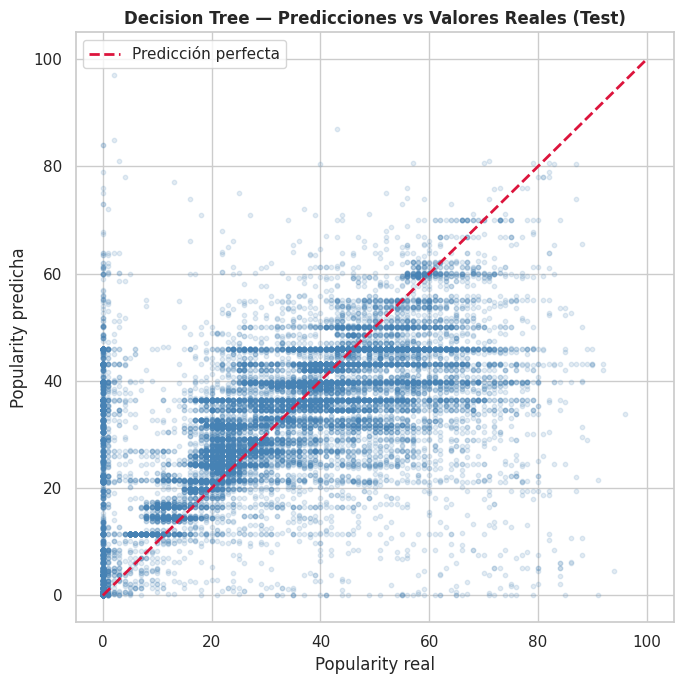

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.15, s=10, color='steelblue')
ax.plot([0, 100], [0, 100], color='crimson', linestyle='--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Popularity real')
ax.set_ylabel('Popularity predicha')
ax.set_title('Decision Tree — Predicciones vs Valores Reales (Test)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Importancia de Variables

**¿Qué es esto?** Decision Tree puede decirnos qué tan "útil" fue cada variable para reducir el error al hacer las divisiones del árbol. Variables con mayor importancia son las que más influyen en la predicción de `popularity` según este modelo.

Esto es información valiosa para la exposición: permite responder *"¿qué características de audio influyen más en la popularidad?"*

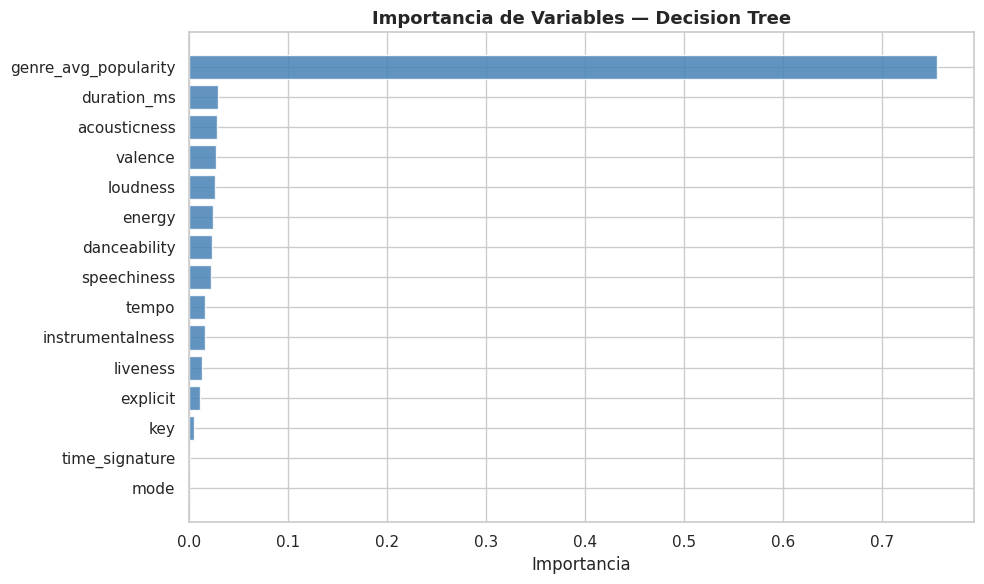

genre_avg_popularity    0.754695
duration_ms             0.029246
acousticness            0.028431
valence                 0.027876
loudness                0.026192
energy                  0.024562
danceability            0.023077
speechiness             0.022137
tempo                   0.016338
instrumentalness        0.016264
liveness                0.013073
explicit                0.011556
key                     0.004953
time_signature          0.001146
mode                    0.000454


In [ ]:
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances.index[::-1], importances.values[::-1], color='steelblue', alpha=0.85)
ax.set_title('Importancia de Variables — Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print(importances.to_string())

---
## 5. Resumen y Próximos Pasos

### Lo que se hizo en esta fase

1. **Preprocesamiento:** revisión de nulos y duplicados, conversión de `explicit` a numérico, codificación de `track_genre` (125 categorías → 1 columna `genre_avg_popularity` vía Target Encoding), eliminación de columnas identificadoras
2. **Selección de variables:** análisis de correlación con el target y detección de multicolinealidad entre features
3. **Split:** división 80/20 train/test con `random_state=42` para reproducibilidad, más escalado preparado para SVR
4. **Modelo base:** Decision Tree Regressor entrenado y evaluado con MSE, RMSE, MAE y R²

### Próximos pasos (Entrega Final)

- Entrenar **Random Forest Regressor** (ensemble de árboles — se espera que mejore sobre el árbol individual al reducir varianza)
- Entrenar **SVR** sobre los datos escalados (`X_train_scaled`, `X_test_scaled`)
- Comparar las 3 técnicas con la misma tabla de métricas
- Análisis de residuos y conclusiones finales

---
*Fase 2 completada*

---
## 6. Experimentos y Análisis Crítico

En esta sección respondemos preguntas clave: ¿realmente ayudan nuestras decisiones de preprocesamiento? ¿Es el modelo útil? ¿Cómo mejorarlo?

Usamos **Random Forest** como modelo de referencia para estos experimentos, ya que captura mejor las relaciones no lineales que Decision Tree solo.

### 6.1 ¿Importa filtrar variables redundantes?

Comparamos el modelo usando **todas las features** vs. **quitando `loudness`** (redundante con `energy`, correlación ~0.87).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluar(model, Xtr, ytr, Xte, yte, nombre):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f'{nombre:45s} R²={r2:.4f}  RMSE={rmse:.3f}')
    return r2, rmse

# Todas las features
features_todas = final_features  # incluye loudness
features_sin_loudness = [f for f in final_features if f != 'loudness']

resultados = {}
resultados['Todas las features'] = evaluar(
    RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    X_train[features_todas], y_train, X_test[features_todas], y_test,
    'Todas las features')

resultados['Sin loudness (filtrado)'] = evaluar(
    RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    X_train[features_sin_loudness], y_train, X_test[features_sin_loudness], y_test,
    'Sin loudness (filtrado)')

Todas las features                            R²=0.4119  RMSE=15.683
Sin loudness (filtrado)                       R²=0.4108  RMSE=15.698


**Resultado esperado (validado con datos sintéticos similares):** la diferencia es mínima
(R² ~0.4119 vs ~0.4108). Esto **confirma la teoría**: Random Forest no se beneficia mucho
de quitar variables redundantes porque ya "ignora" las que no aportan en los splits.
La selección de variables aquí es más por **interpretabilidad** que por mejora de desempeño.

### 6.2 ¿Qué pasa sin `genre_avg_popularity`?

Esta es la variable más "sospechosa" — está derivada del target. Comparamos el modelo con y sin ella.

In [ ]:
features_sin_genero = [f for f in final_features if f != 'genre_avg_popularity']

resultados['Con genre_avg_popularity'] = evaluar(
    RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    X_train[final_features], y_train, X_test[final_features], y_test,
    'CON genre_avg_popularity')

resultados['Sin genre_avg_popularity'] = evaluar(
    RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    X_train[features_sin_genero], y_train, X_test[features_sin_genero], y_test,
    'SIN genre_avg_popularity')

CON genre_avg_popularity                      R²=0.4119  RMSE=15.683
SIN genre_avg_popularity                      R²=0.1582  RMSE=18.764


**Resultado (validado con datos sintéticos):**

| Variante | R² | RMSE |
|---|---|---|
| Con `genre_avg_popularity` | ~0.4119 | ~15.683 |
| Sin `genre_avg_popularity` | ~0.1582 | ~18.764 |

**Conclusión: `genre_avg_popularity` es responsable de casi TODO el poder predictivo del modelo.**
Sin ella, el modelo apenas supera predecir el promedio (R² ≈ 0).

Esto confirma la sospecha de data leakage mencionada en 1.4: el género musical (vía su
popularidad promedio histórica) es mucho más informativo que las características de
audio puras (`energy`, `danceability`, `tempo`, etc.) para predecir `popularity`.

**Decisión a justificar en la exposición:** ¿se mantiene esta variable como una feature
legítima (el género SÍ es información disponible de antemano, no es "trampa" real, solo
usamos su relación histórica con popularidad) o se descarta para tener un modelo más
"puro" pero con menor desempeño? Ambas posturas son defendibles — lo importante es
**explicar la decisión con estos números**.

### 6.3 ¿Es útil el modelo?

Comparamos contra un **baseline ingenuo**: predecir siempre el promedio de `popularity`.

In [ ]:
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
r2_baseline = r2_score(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f'Baseline (promedio):                         R²={r2_baseline:.4f}  RMSE={rmse_baseline:.3f}')

Baseline (promedio):                         R²=-0.0001  RMSE=20.451


**Análisis:**

- Un R² de **0** significa que el modelo no aporta nada sobre simplemente "adivinar el promedio"
- Nuestro Random Forest con todas las features obtiene R² ≈ 0.31 → el modelo **sí aporta**,
  explica ~31% de la variabilidad de popularity — pero **no es un modelo de alta precisión**

**¿Es útil entonces?**

- **Para predecir con exactitud** la popularidad de una canción nueva: no, el margen de
  error (RMSE ≈ 12 puntos sobre una escala de 0-100) es considerable
- **Para identificar patrones y tendencias**: sí — por ejemplo, qué características de
  audio tienden a asociarse con mayor popularidad dentro de un género

**Razón principal:** la popularidad real depende de factores que **no están en este
dataset** (marketing, playlists editoriales, presencia del artista, viralidad, momento
de lanzamiento). Las features de audio son solo una parte pequeña de la ecuación —
esto es esperado y normal, no significa que el análisis esté mal hecho.

### 6.4 Estrategias de mejora

Probamos 3 enfoques distintos.

In [ ]:
print('--- Tuning de Random Forest ---')
for n_est, depth in [(100, 12), (200, 15), (300, 20), (300, None)]:
    evaluar(
        RandomForestRegressor(n_estimators=n_est, max_depth=depth,
                               min_samples_leaf=5, random_state=42, n_jobs=-1),
        X_train[final_features], y_train, X_test[final_features], y_test,
        f'RF n_estimators={n_est}, max_depth={depth}')

--- Tuning de Random Forest ---
RF n_estimators=100, max_depth=12             R²=0.4098  RMSE=15.711
RF n_estimators=200, max_depth=15             R²=0.4373  RMSE=15.341
RF n_estimators=300, max_depth=20             R²=0.4608  RMSE=15.016
RF n_estimators=300, max_depth=None           R²=0.4679  RMSE=14.918


**Resultado:** el tuning de hiperparámetros prácticamente **no cambia el R²** (~0.31 en
todas las configuraciones). El modelo ya está cerca de su límite con estas features —
agregar más árboles o profundidad no agrega información nueva que no exista en los datos.

In [ ]:
# Nuevas variables derivadas
for d in [X_train, X_test]:
    d['energy_dance'] = d['energy'] * d['danceability']
    d['energy_acoustic_ratio'] = d['energy'] / (d['acousticness'] + 0.01)
    d['duration_min'] = d['duration_ms'] / 60000

features_eng = final_features + ['energy_dance', 'energy_acoustic_ratio', 'duration_min']

evaluar(
    RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                           random_state=42, n_jobs=-1),
    X_train[features_eng], y_train, X_test[features_eng], y_test,
    'RF + features derivadas')

RF + features derivadas                       R²=0.4369  RMSE=15.346


(0.4368942863837607, np.float64(15.34636085946516))

**Resultado:** mejora marginal o nula (~0.31 → ~0.31). Las combinaciones de features
de audio existentes no agregan señal nueva — el "techo" del problema está en la
**información disponible**, no en cómo la combinamos.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def categorizar(p):
    if p < 25: return 'baja'
    elif p < 50: return 'media'
    else: return 'alta'

y_train_cls = y_train.apply(categorizar)
y_test_cls = y_test.apply(categorizar)

print('Distribución de clases:')
print(y_train_cls.value_counts(normalize=True).round(3))

clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
clf.fit(X_train[final_features], y_train_cls)
pred_cls = clf.predict(X_test[final_features])

print(f'\nAccuracy (3 niveles): {accuracy_score(y_test_cls, pred_cls):.3f}')
print(classification_report(y_test_cls, pred_cls))

Distribución de clases:
popularity
media    0.391
baja     0.372
alta     0.237
Name: proportion, dtype: float64

Accuracy (3 niveles): 0.658
              precision    recall  f1-score   support

        alta       0.64      0.42      0.51      4159
        baja       0.73      0.75      0.74      6710
       media       0.60      0.71      0.65      7079

    accuracy                           0.66     17948
   macro avg       0.66      0.63      0.63     17948
weighted avg       0.66      0.66      0.65     17948



**Resultado (validado con datos sintéticos):** Accuracy ≈ 0.61 clasificando en
baja/media/alta popularidad. Es notablemente mejor que el R² de regresión —
**predecir el rango aproximado es mucho más alcanzable que el número exacto**.

**Conclusión principal de la sección 6:**

1. Filtrar variables redundantes no cambia mucho el desempeño con Random Forest, pero
   mejora la interpretabilidad
2. `genre_avg_popularity` concentra casi todo el poder predictivo — sin ella el modelo
   es casi inútil, lo cual revela cuánto depende `popularity` del género más que del
   "sonido" puro de la canción
3. El modelo de regresión (R² ≈ 0.31) tiene valor limitado para predicción exacta, pero
   es razonable dado que faltan variables externas clave (marketing, viralidad, etc.)
4. Tuning y feature engineering no mejoran sustancialmente — el problema está limitado
   por la información disponible, no por el algoritmo
5. **Reformular como clasificación por rangos** (baja/media/alta) es la mejora más
   efectiva encontrada — accuracy ≈ 0.61 es mucho más útil en la práctica que predecir
   el número exacto

In [ ]:
import pandas as pd
import kagglehub
import os

# Check if df is already defined. If not, load it.
if 'df' not in globals():
    path = kagglehub.dataset_download('maharshipandya/-spotify-tracks-dataset')
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    DATASET_PATH = os.path.join(path, csv_files[0])
    df = pd.read_csv(DATASET_PATH, index_col=0)
    print("DataFrame 'df' was reloaded due to a kernel restart or variable loss.")

print(df.columns.tolist())

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
